In [1]:
# 0,1: 00 for psi_1, 01 for psi_2 ...
# 2,3: For states
# 4,5: Ancillary qubits

In [2]:
from qiskit import QuantumCircuit
from numpy import sqrt

def circuit_init():
    qc = QuantumCircuit(6)
    return qc

def PREP(qc):
    desired_vector = [
        1/sqrt(3), 0, 0, 0,
        1/(4*sqrt(3)), 1/4, 1/4, sqrt(3)/4,
        1/(4*sqrt(3)), -1/4, -1/4, sqrt(3)/4,
        0, 0, 0, 0
    ]
    qc.initialize(desired_vector, [3,2,1,0])
    return qc

In [3]:
from qiskit.circuit.library.standard_gates import RXGate,RYGate, RZGate
from qiskit.circuit.library import MCXGate
from qiskit.circuit.library.standard_gates import XGate
from pennylane.templates.state_preparations.mottonen import compute_theta, gray_code
from numpy import array, log2

def RR_X(qc, wires, params):
    qc.append(RXGate(params[0]),[wires[0]])
    qc.append(RXGate(params[1]),[wires[1]])

def RR_Z(qc, wires, params):
    qc.append(RZGate(params[0]),[wires[0]])
    qc.append(RZGate(params[1]),[wires[1]])


def CRR_X(qc, wires, state, params):
    qc.append(RXGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(RXGate(params[1]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    return qc

def CRR_Z(qc, wires, state, params):
    qc.append(RZGate(params[0]).control(1,ctrl_state = state[::-1]), [wires[0], wires[1]])  # Control: wires[0] Target: wires[1]
    qc.append(RZGate(params[1]).control(1,ctrl_state = state[::-1]), [wires[0], wires[2]])  # Control: wires[0] Target: wires[2]
    return qc

def CCRR_X(qc, wires, state, params):
    qc.append(RXGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(RXGate(params[1]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]
    return qc

def CCRR_Z(qc, wires, state, params):
    qc.append(RZGate(params[0]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[2]])  # Control: wires[0] wires[1]
    qc.append(RZGate(params[1]).control(2, ctrl_state = state[::-1]), [wires[0], wires[1],wires[3]])  # Control: wires[0] wires[1]
    return qc

def U_CCR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-1
    code = gray_code(2)
    n_selections = len(code)

    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.ry(params[i],wires[2])
        qc.cx(wires[num_Ucontrols-1 - control_order[i]],wires[2])
    return qc

def U_CCcR_decom(qc,wires,params):
    # Make sure that control qubits should be increasing order
    params = array(params)
    params = compute_theta(params) #can be on/off

    num_Ucontrols = len(wires)-2
    code = gray_code(2)
    n_selections = len(code)
    control_order = [int(log2(int(code[i], 2) ^ int(code[(i + 1) % n_selections], 2))) for i in range(n_selections)]

    for i in range(n_selections):
        qc.cry(params[i],wires[2],wires[3])
        CCX(qc,[wires[num_Ucontrols-1 - control_order[i]],wires[2],wires[3]],'11')

    return qc

def CCX(qc, wires, state):
    mcx_gate = MCXGate(num_ctrl_qubits=2,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2]])
    return qc

def CCCX(qc, wires, state):
    mcx_gate = MCXGate(num_ctrl_qubits=3,ctrl_state=state[::-1])
    qc.append(mcx_gate, [wires[0], wires[1],wires[2], wires[3]])
    return qc

def CX01(qc, wires):
    qc.append(
        XGate().control(1, ctrl_state='1'),
        [wires[0], wires[1]])
    return qc

In [4]:
from qiskit.circuit.library.standard_gates import RYGate

from numpy import pi


def Ansatz(qc, wires, params):


    #Big made by HEA
    RR_X(qc,wires[0:2],params[0:2])
    RR_Z(qc,wires[0:2],params[2:4])
    qc.cx(wires[0],wires[1])

    #Module 1
    U_CCR_decom(qc,wires[0:3],params[4:8])
    CRR_X(qc,[wires[2],wires[0],wires[1]],'0',params[8:10])
    CRR_Z(qc,[wires[2],wires[0],wires[1]],'0',params[10:12])
    CCX(qc,[wires[0],wires[2], wires[1]],'10')
    CRR_X(qc,[wires[2],wires[0],wires[1]],'1',params[12:14])
    CRR_Z(qc,[wires[2],wires[0],wires[1]],'1',params[14:16])
    CCX(qc,[wires[0],wires[2], wires[1]],'11')

    #Module 2
    U_CCcR_decom(qc, wires[0:4],params[16:20])
    CCRR_X(qc,[wires[2],wires[3],wires[0],wires[1]],'10',params[20:22])
    CCRR_Z(qc,[wires[2],wires[3],wires[0],wires[1]],'10',params[22:24])
    CCCX(qc,[wires[0],wires[2],wires[3],wires[1]],'110')
    CCRR_X(qc,[wires[2],wires[3],wires[0],wires[1]],'11',params[24:26])
    CCRR_Z(qc,[wires[2],wires[3],wires[0],wires[1]],'11',params[26:28])
    CCCX(qc,[wires[0],wires[2],wires[3],wires[1]],'111')

    CX01(qc, [wires[3],wires[2]])
    qc.measure_all()
    return qc

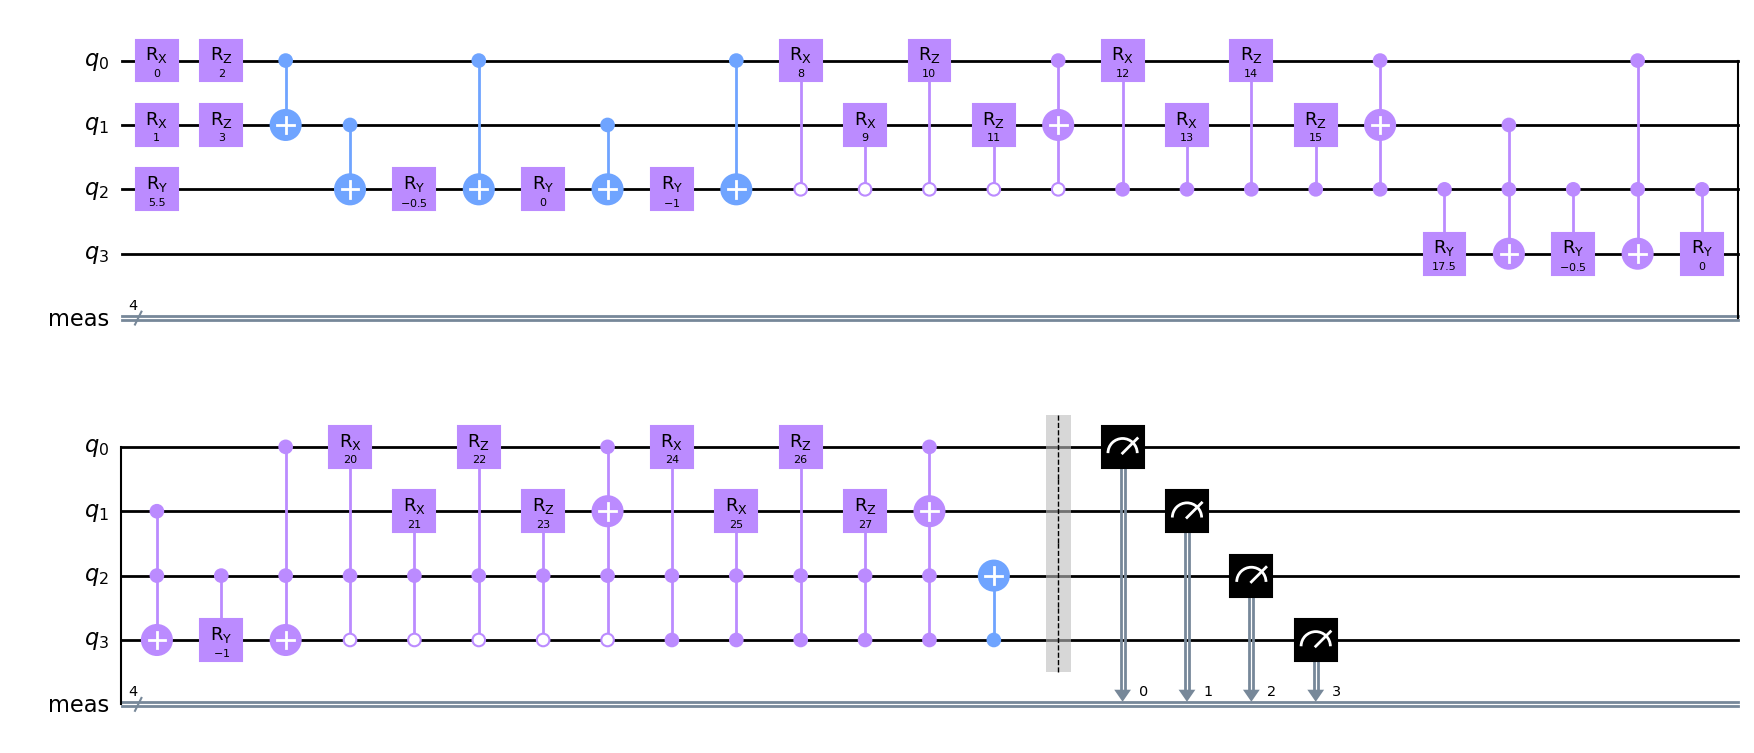

In [5]:
from numpy.random import rand
num_params=28
params = list(range(num_params))
qc = QuantumCircuit(4)
#PREP(qc)
Ansatz(qc, [0,1,2,3] , params)
qc.draw(output='mpl', style = 'clifford')

In [ ]:
from qiskit_aer import AerSimulator
from qiskit import transpile

from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms.utils import algorithm_globals

import numpy as np
import os
import time


# ============================================================
# Simulator
# ============================================================

aersim = AerSimulator()


# ============================================================
# Settings
# ============================================================

num_times = 30
num_shots = 10000

optimizer_name = "SPSA"
maxiter = 2000

# SPSA-specific settings
learning_rate = 0.05
perturbation = 0.1

BASE_SEED = 150

report_filename = f"{optimizer_name}_report.txt"

# ============================================================
# High-Shot Evaluation Settings
# ============================================================

evaluation_num_times = 20
evaluation_num_shots = 100000

EVALUATION_BASE_SEED = 10000

evaluation_seeds = np.array(
    [
        EVALUATION_BASE_SEED + i
        for i in range(evaluation_num_times)
    ],
    dtype=int
)


# ============================================================
# Storage
# ============================================================

final_optimized_values = []

initial_params_all_runs = []
optimal_params_all_runs = []

optimization_success_all_runs = []
optimization_status_all_runs = []
optimization_message_all_runs = []

optimization_nit_all_runs = []
optimization_nfev_all_runs = []

reached_maxiter_all_runs = []

# ------------------------------------------------------------
# Runtime Storage
# ------------------------------------------------------------

optimization_wall_times = []


# ------------------------------------------------------------
# High-Shot Evaluation Storage
# ------------------------------------------------------------

evaluation_values_all_runs = []

evaluation_mean_all_runs = []
evaluation_std_all_runs = []
evaluation_min_all_runs = []
evaluation_max_all_runs = []


# ============================================================
# Objective Function
# ============================================================

def objective_function(
    params,
    run_seed,
    shots=None,
    print_result=True
):

    if shots is None:
        shots = num_shots


    # --------------------------------------------------------
    # Construct circuit
    # --------------------------------------------------------

    qc = circuit_init()

    PREP(qc)

    Ansatz(
        qc,
        [2, 3, 4, 5],
        params
    )


    qc_reverse = qc.reverse_bits()


    # --------------------------------------------------------
    # Transpile
    # --------------------------------------------------------

    t_qc = transpile(
        qc_reverse,
        aersim,
        seed_transpiler=run_seed
    )


    # --------------------------------------------------------
    # Run simulator
    # --------------------------------------------------------

    job = aersim.run(
        t_qc,
        shots=shots,
        seed_simulator=run_seed
    )


    result = job.result()

    counts = result.get_counts()


    # --------------------------------------------------------
    # Target counts
    # --------------------------------------------------------

    tar_00 = 0
    tar_01 = 0
    tar_10 = 0


    for outcome, count in counts.items():

        if outcome[0:2] == "00":

            if outcome[4:6] == "00":

                tar_00 += count


        if outcome[0:2] == "01":

            if outcome[4:6] == "01":

                tar_01 += count


        if outcome[0:2] == "10":

            if outcome[4:6] == "10":

                tar_10 += count


    # --------------------------------------------------------
    # Success probability
    # --------------------------------------------------------

    p_suc = (
        tar_00
        + tar_01
        + tar_10
    ) / shots


    if print_result:

        print(
            f"success_probability = "
            f"{p_suc:.8f}"
        )


    # --------------------------------------------------------
    # SPSA minimizes.
    #
    # We want to maximize p_suc,
    # therefore minimize 1 / p_suc.
    # --------------------------------------------------------

    if p_suc == 0:

        return 1e10


    return 1.0 / p_suc


# ============================================================
# SPSA Callback
# ============================================================

def spsa_callback(
    nfev,
    parameters,
    value,
    stepsize,
    accepted
):

    if value > 0 and value < 1e10:

        success_probability = (
            1.0 / value
        )

    else:

        success_probability = 0.0


    print(
        f"SPSA evaluation {nfev:5d} | "
        f"p_suc = {success_probability:.8f} | "
        f"objective = {value:.8f} | "
        f"step = {stepsize:.6f} | "
        f"accepted = {accepted}"
    )


# ============================================================
# Run Optimization
# ============================================================

# Measures the complete workflow:
# optimization + final evaluations + high-shot evaluations + overhead.
total_wall_start = time.perf_counter()

for run in range(num_times):


    # ========================================================
    # Optimization Seed
    # ========================================================

    run_seed = (
        BASE_SEED + run
    )


    rng = np.random.default_rng(
        run_seed
    )


    print(
        "\n"
        + "=" * 80
    )


    print(
        f"Optimization Run "
        f"{run + 1}/{num_times}"
    )


    print(
        f"Optimization Seed : "
        f"{run_seed}"
    )


    print(
        "=" * 80
    )


    # ========================================================
    # Generate Random Initial Parameters
    # ========================================================

    initial_params = rng.random(
        num_params
    )


    # --------------------------------------------------------
    # Seed SPSA internal randomness
    # --------------------------------------------------------

    algorithm_globals.random_seed = (
        run_seed
    )


    initial_params_all_runs.append(
        initial_params.copy()
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    # ========================================================
    # Create SPSA Optimizer
    # ========================================================

    optimizer = SPSA(
        maxiter=maxiter,
        learning_rate=learning_rate,
        perturbation=perturbation,
        callback=spsa_callback
    )


    # ========================================================
    # Run SPSA Optimization
    # ========================================================

    print(
        "\nStarting SPSA optimization..."
    )


    optimization_start = time.perf_counter()

    result = optimizer.minimize(

        fun=lambda params: objective_function(
            params,
            run_seed,
            shots=num_shots,
            print_result=True
        ),

        x0=initial_params
    )

    optimization_end = time.perf_counter()

    run_optimization_wall_time = (
        optimization_end
        - optimization_start
    )

    optimization_wall_times.append(
        run_optimization_wall_time
    )

    print(
        f"Optimization Wall-Clock Time : "
        f"{run_optimization_wall_time:.6f} s"
    )


    # ========================================================
    # Optimization Status
    # ========================================================

    raw_success = getattr(
        result,
        "success",
        None
    )


    if raw_success is None:

        optimization_success = None

    else:

        optimization_success = bool(
            raw_success
        )


    optimization_status = getattr(
        result,
        "status",
        None
    )


    raw_message = getattr(
        result,
        "message",
        None
    )


    if raw_message is None:

        optimization_message = (
            "Not provided by SPSA"
        )

    else:

        optimization_message = str(
            raw_message
        )


    optimization_nit = getattr(
        result,
        "nit",
        None
    )


    optimization_nfev = getattr(
        result,
        "nfev",
        None
    )


    # ========================================================
    # Detect Maximum Iteration Limit
    # ========================================================

    reached_maxiter = False


    if optimization_nit is not None:

        if optimization_nit >= maxiter:

            reached_maxiter = True


    # ========================================================
    # Store Optimization Status
    # ========================================================

    optimization_success_all_runs.append(
        optimization_success
    )


    optimization_status_all_runs.append(
        optimization_status
    )


    optimization_message_all_runs.append(
        optimization_message
    )


    optimization_nit_all_runs.append(
        optimization_nit
    )


    optimization_nfev_all_runs.append(
        optimization_nfev
    )


    reached_maxiter_all_runs.append(
        reached_maxiter
    )


    # ========================================================
    # Optimal Parameters
    # ========================================================

    optimal_params = (
        result.x.copy()
    )


    optimal_params_all_runs.append(
        optimal_params.copy()
    )


    # ========================================================
    # Final Optimization-Shot Evaluation
    #
    # This is the original optimized value:
    #     shots = 10,000
    #     seed  = optimization run seed
    # ========================================================

    final_objective = objective_function(
        optimal_params,
        run_seed,
        shots=num_shots,
        print_result=False
    )


    if final_objective >= 1e10:

        final_value = 0.0

    else:

        final_value = (
            1.0 / final_objective
        )


    final_optimized_values.append(
        final_value
    )


    # ========================================================
    # High-Shot Evaluation
    # ========================================================

    print(
        "\n"
        + "-" * 80
    )


    print(
        "HIGH-SHOT EVALUATION OF "
        "OPTIMIZED PARAMETERS"
    )


    print(
        "-" * 80
    )


    print(
        f"Optimization Shots     : "
        f"{num_shots}"
    )


    print(
        f"Evaluation Shots       : "
        f"{evaluation_num_shots}"
    )


    print(
        f"Number of Evaluations : "
        f"{evaluation_num_times}"
    )


    print(
        "\nEvaluation Results:"
    )


    evaluation_values = []


    # --------------------------------------------------------
    # Same 20 evaluation seeds for every optimized parameter
    # set.
    #
    # Evaluation seeds themselves are NOT printed here.
    # --------------------------------------------------------

    for eval_index, eval_seed in enumerate(
        evaluation_seeds
    ):


        eval_objective = objective_function(
            optimal_params,
            int(eval_seed),
            shots=evaluation_num_shots,
            print_result=False
        )


        if eval_objective >= 1e10:

            eval_value = 0.0

        else:

            eval_value = (
                1.0 / eval_objective
            )


        evaluation_values.append(
            eval_value
        )


        print(
            f"Evaluation "
            f"{eval_index + 1:2d}/"
            f"{evaluation_num_times:2d}"
            f" | Value = "
            f"{eval_value:.8f}"
        )


    # ========================================================
    # Evaluation Statistics
    # ========================================================

    evaluation_values = np.array(
        evaluation_values,
        dtype=float
    )


    evaluation_mean = np.mean(
        evaluation_values
    )


    evaluation_std = np.std(
        evaluation_values
    )


    evaluation_min = np.min(
        evaluation_values
    )


    evaluation_max = np.max(
        evaluation_values
    )


    # ========================================================
    # Store Evaluation Results
    # ========================================================

    evaluation_values_all_runs.append(
        evaluation_values.copy()
    )


    evaluation_mean_all_runs.append(
        evaluation_mean
    )


    evaluation_std_all_runs.append(
        evaluation_std
    )


    evaluation_min_all_runs.append(
        evaluation_min
    )


    evaluation_max_all_runs.append(
        evaluation_max
    )


    # ========================================================
    # Individual Run Report
    # ========================================================

    print(
        "\n"
        + "=" * 80
    )


    print(
        f"RUN {run + 1} RESULT"
    )


    print(
        "=" * 80
    )


    print(
        f"Optimization Success : "
        f"{optimization_success}"
    )


    print(
        f"Reached MaxIter      : "
        f"{reached_maxiter}"
    )


    print(
        f"Status               : "
        f"{optimization_status}"
    )


    print(
        f"Message              : "
        f"{optimization_message}"
    )


    print(
        f"Iterations           : "
        f"{optimization_nit}"
    )


    print(
        f"Function Evaluations : "
        f"{optimization_nfev}"
    )


    print(
        f"Optimization Time    : "
        f"{run_optimization_wall_time:.6f} s"
    )


    print(
        f"Optimizer Objective  : "
        f"{result.fun}"
    )


    print(
        f"Final Objective Value: "
        f"{final_objective}"
    )


    print(
        "\n"
        + "-" * 80
    )


    print(
        "OPTIMIZED AND HIGH-SHOT "
        "EVALUATED VALUES"
    )


    print(
        "-" * 80
    )


    print(
        f"Final Optimized Value : "
        f"{final_value:.8f}"
    )


    print(
        f"Evaluated Mean        : "
        f"{evaluation_mean:.8f}"
    )


    print(
        f"Evaluated Std         : "
        f"{evaluation_std:.8f}"
    )


    print(
        f"Evaluated Min         : "
        f"{evaluation_min:.8f}"
    )


    print(
        f"Evaluated Max         : "
        f"{evaluation_max:.8f}"
    )


    print(
        "\nAll Evaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values,
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params,
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params,
            precision=10,
            separator=", "
        )
    )


    print(
        "=" * 80
    )


# ============================================================
# Runtime Statistics
# ============================================================

total_wall_end = time.perf_counter()

total_wall_time = (
    total_wall_end
    - total_wall_start
)

optimization_wall_times = np.array(
    optimization_wall_times,
    dtype=float
)

total_optimization_wall_time = np.sum(
    optimization_wall_times
)

mean_optimization_wall_time = np.mean(
    optimization_wall_times
)

std_optimization_wall_time = np.std(
    optimization_wall_times
)


# ============================================================
# Convert Results to NumPy Arrays
# ============================================================

final_optimized_values = np.array(
    final_optimized_values,
    dtype=float
)


initial_params_all_runs = np.array(
    initial_params_all_runs
)


optimal_params_all_runs = np.array(
    optimal_params_all_runs
)


evaluation_values_all_runs = np.array(
    evaluation_values_all_runs,
    dtype=float
)


evaluation_mean_all_runs = np.array(
    evaluation_mean_all_runs,
    dtype=float
)


evaluation_std_all_runs = np.array(
    evaluation_std_all_runs,
    dtype=float
)


evaluation_min_all_runs = np.array(
    evaluation_min_all_runs,
    dtype=float
)


evaluation_max_all_runs = np.array(
    evaluation_max_all_runs,
    dtype=float
)


# ============================================================
# Original Optimization Statistics
# ============================================================

maximum_value = np.max(
    final_optimized_values
)


mean_value = np.mean(
    final_optimized_values
)


std_value = np.std(
    final_optimized_values
)


maximum_run_index = np.argmax(
    final_optimized_values
)


maximum_run = (
    maximum_run_index
    + 1
)


# ============================================================
# High-Shot Evaluation Statistics
# ============================================================

maximum_evaluated_mean = np.max(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run_index = np.argmax(
    evaluation_mean_all_runs
)


maximum_evaluated_mean_run = (
    maximum_evaluated_mean_run_index
    + 1
)


mean_of_evaluated_means = np.mean(
    evaluation_mean_all_runs
)


std_of_evaluated_means = np.std(
    evaluation_mean_all_runs
)


# ============================================================
# Iteration Statistics
# ============================================================

nit_values = np.array(
    [
        nit
        for nit
        in optimization_nit_all_runs
        if nit is not None
    ],
    dtype=float
)


if len(nit_values) > 0:

    mean_nit = np.mean(
        nit_values
    )


    std_nit = np.std(
        nit_values
    )

else:

    mean_nit = np.nan
    std_nit = np.nan


# ============================================================
# Function Evaluation Statistics
# ============================================================

nfev_values = np.array(
    [
        nfev
        for nfev
        in optimization_nfev_all_runs
        if nfev is not None
    ],
    dtype=float
)


if len(nfev_values) > 0:

    mean_nfev = np.mean(
        nfev_values
    )


    std_nfev = np.std(
        nfev_values
    )

else:

    mean_nfev = np.nan
    std_nfev = np.nan


# ============================================================
# SPSA Run Statistics
# ============================================================

# SPSA may not provide a SciPy-style success flag.

num_successful_runs = sum(
    value is True
    for value in optimization_success_all_runs
)


num_failed_runs = sum(
    value is False
    for value in optimization_success_all_runs
)


num_unknown_success = sum(
    value is None
    for value in optimization_success_all_runs
)


num_reached_maxiter = sum(
    reached_maxiter_all_runs
)


# ============================================================
# Best Run According to Original Optimized Value
# ============================================================

best_initial_params = (
    initial_params_all_runs[
        maximum_run_index
    ]
)


best_optimal_params = (
    optimal_params_all_runs[
        maximum_run_index
    ]
)


# ============================================================
# Best Run According to High-Shot Evaluated Mean
# ============================================================

best_evaluated_initial_params = (
    initial_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_optimal_params = (
    optimal_params_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


best_evaluated_values = (
    evaluation_values_all_runs[
        maximum_evaluated_mean_run_index
    ]
)


# ============================================================
# Print Final Report
# ============================================================

print("\n")


print(
    "=" * 100
)


print(
    "FINAL OPTIMIZATION AND "
    "HIGH-SHOT EVALUATION REPORT"
)


print(
    "=" * 100
)


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

print(
    f"Optimizer               : "
    f"{optimizer_name}"
)


print(
    f"Learning Rate           : "
    f"{learning_rate}"
)


print(
    f"Perturbation            : "
    f"{perturbation}"
)


print(
    f"Max Iteration           : "
    f"{maxiter}"
)


print(
    f"Number of Runs          : "
    f"{num_times}"
)


print(
    f"Optimization Shots      : "
    f"{num_shots}"
)


print(
    f"Optimization Base Seed  : "
    f"{BASE_SEED}"
)


print(
    f"Evaluation Shots        : "
    f"{evaluation_num_shots}"
)


print(
    f"Evaluations Per Run     : "
    f"{evaluation_num_times}"
)


print(
    f"Evaluation Base Seed    : "
    f"{EVALUATION_BASE_SEED}"
)


# Evaluation seeds printed ONCE only.
print(
    "Evaluation Seeds        : "
    + np.array2string(
        evaluation_seeds,
        separator=", "
    )
)


print(
    "=" * 100
)


# ============================================================
# Results for Every Run
# ============================================================

for i in range(num_times):


    print(
        f"\nRun {i + 1:2d}"
    )


    print(
        "-" * 100
    )


    print(
        f"Optimization Seed : "
        f"{BASE_SEED + i}"
    )


    print(
        f"Optimized Value   : "
        f"{final_optimized_values[i]:.8f}"
    )


    print(
        f"Evaluated Mean    : "
        f"{evaluation_mean_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Std     : "
        f"{evaluation_std_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Min     : "
        f"{evaluation_min_all_runs[i]:.8f}"
    )


    print(
        f"Evaluated Max     : "
        f"{evaluation_max_all_runs[i]:.8f}"
    )


    print(
        f"Success           : "
        f"{optimization_success_all_runs[i]}"
    )


    print(
        f"Reached MaxIter   : "
        f"{reached_maxiter_all_runs[i]}"
    )


    print(
        f"Status            : "
        f"{optimization_status_all_runs[i]}"
    )


    print(
        f"Message           : "
        f"{optimization_message_all_runs[i]}"
    )


    print(
        f"Iterations        : "
        f"{optimization_nit_all_runs[i]}"
    )


    print(
        f"Function Evals    : "
        f"{optimization_nfev_all_runs[i]}"
    )


    print(
        f"Optimization Time : "
        f"{optimization_wall_times[i]:.6f} s"
    )


    print(
        "\nEvaluated Values:"
    )


    print(
        np.array2string(
            evaluation_values_all_runs[i],
            precision=8,
            separator=", "
        )
    )


    print(
        "\nInitial Parameters:"
    )


    print(
        np.array2string(
            initial_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


    print(
        "\nOptimal Parameters:"
    )


    print(
        np.array2string(
            optimal_params_all_runs[i],
            precision=10,
            separator=", "
        )
    )


    print(
        "-" * 100
    )


# ============================================================
# Summary
# ============================================================

print(
    "\nSUMMARY"
)


print(
    "=" * 100
)


# ------------------------------------------------------------
# Original Optimization-Shot Results
# ------------------------------------------------------------

print(
    "\nOriginal Optimization-Shot Results:"
)


print(
    f"Maximum Optimized Value : "
    f"{maximum_value:.8f}"
)


print(
    f"Maximum Run             : "
    f"{maximum_run}"
)


print(
    f"Mean Optimized Value    : "
    f"{mean_value:.8f}"
)


print(
    f"Std Optimized Value     : "
    f"{std_value:.8f}"
)


# ------------------------------------------------------------
# High-Shot Evaluation Results
# ------------------------------------------------------------

print(
    "\nHigh-Shot Evaluation Results:"
)


print(
    f"Best Evaluated Mean     : "
    f"{maximum_evaluated_mean:.8f}"
)


print(
    f"Best Evaluated Mean Run : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Mean of Evaluated Means : "
    f"{mean_of_evaluated_means:.8f}"
)


print(
    f"Std of Evaluated Means  : "
    f"{std_of_evaluated_means:.8f}"
)


# ------------------------------------------------------------
# Optimizer Statistics
# ------------------------------------------------------------

print(
    "\nOptimizer Statistics:"
)


print(
    f"Mean Iterations         : "
    f"{mean_nit:.2f}"
)


print(
    f"Std Iterations          : "
    f"{std_nit:.2f}"
)


print(
    f"Mean Function Evals     : "
    f"{mean_nfev:.2f}"
)


print(
    f"Std Function Evals      : "
    f"{std_nfev:.2f}"
)


print(
    f"Successful Runs         : "
    f"{num_successful_runs}/"
    f"{num_times}"
)


print(
    f"Failed Runs             : "
    f"{num_failed_runs}/"
    f"{num_times}"
)


print(
    f"Success Not Reported    : "
    f"{num_unknown_success}/"
    f"{num_times}"
)


print(
    f"Reached MaxIter         : "
    f"{num_reached_maxiter}/"
    f"{num_times}"
)


# ------------------------------------------------------------
# Computational Runtime Statistics
# ------------------------------------------------------------

print(
    "\nComputational Runtime Statistics:"
)

print(
    f"Total Wall-Clock Time          : "
    f"{total_wall_time:.6f} s"
)

print(
    f"Total Optimization Time        : "
    f"{total_optimization_wall_time:.6f} s"
)

print(
    f"Time per Complete Opt. Run     : "
    f"{mean_optimization_wall_time:.6f} s"
)

print(
    f"Std Optimization Time per Run  : "
    f"{std_optimization_wall_time:.6f} s"
)


# ============================================================
# Best Run According to Original Optimized Value
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO "
    "ORIGINAL OPTIMIZED VALUE"
)


print(
    "=" * 100
)


print(
    f"Run             : "
    f"{maximum_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        evaluation_values_all_runs[
            maximum_run_index
        ],
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_optimal_params,
        precision=10,
        separator=", "
    )
)


# ============================================================
# Best Run According to High-Shot Evaluated Mean
# ============================================================

print(
    "\n"
    + "=" * 100
)


print(
    "BEST RUN ACCORDING TO "
    "HIGH-SHOT EVALUATED MEAN"
)


print(
    "=" * 100
)


print(
    f"Run             : "
    f"{maximum_evaluated_mean_run}"
)


print(
    f"Optimized Value : "
    f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Mean  : "
    f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Std   : "
    f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Min   : "
    f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    f"Evaluated Max   : "
    f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}"
)


print(
    "\nEvaluated Values:"
)


print(
    np.array2string(
        best_evaluated_values,
        precision=8,
        separator=", "
    )
)


print(
    "\nInitial Parameters:"
)


print(
    np.array2string(
        best_evaluated_initial_params,
        precision=10,
        separator=", "
    )
)


print(
    "\nOptimal Parameters:"
)


print(
    np.array2string(
        best_evaluated_optimal_params,
        precision=10,
        separator=", "
    )
)


print(
    "=" * 100
)


# ============================================================
# Save Report to TXT
# ============================================================

with open(
    report_filename,
    "w"
) as f:


    # ========================================================
    # Header
    # ========================================================

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "FINAL OPTIMIZATION AND "
        "HIGH-SHOT EVALUATION REPORT\n"
    )


    f.write(
        "=" * 100
        + "\n\n"
    )


    # ========================================================
    # Settings
    # ========================================================

    f.write(
        f"Optimizer               : "
        f"{optimizer_name}\n"
    )


    f.write(
        f"Learning Rate           : "
        f"{learning_rate}\n"
    )


    f.write(
        f"Perturbation            : "
        f"{perturbation}\n"
    )


    f.write(
        f"Max Iteration           : "
        f"{maxiter}\n"
    )


    f.write(
        f"Number of Runs          : "
        f"{num_times}\n"
    )


    f.write(
        f"Optimization Shots      : "
        f"{num_shots}\n"
    )


    f.write(
        f"Optimization Base Seed  : "
        f"{BASE_SEED}\n"
    )


    f.write(
        f"Evaluation Shots        : "
        f"{evaluation_num_shots}\n"
    )


    f.write(
        f"Evaluations Per Run     : "
        f"{evaluation_num_times}\n"
    )


    f.write(
        f"Evaluation Base Seed    : "
        f"{EVALUATION_BASE_SEED}\n"
    )


    # Evaluation seeds saved ONCE only.
    f.write(
        "Evaluation Seeds        : "
    )


    f.write(
        np.array2string(
            evaluation_seeds,
            separator=", "
        )
    )


    f.write(
        "\n\n"
    )


    # ========================================================
    # Results for Every Run
    # ========================================================

    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "RESULTS FOR EACH RUN\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    for i in range(num_times):


        f.write(
            f"\nRun {i + 1:2d}\n"
        )


        f.write(
            "-" * 100
            + "\n"
        )


        f.write(
            f"Optimization Seed : "
            f"{BASE_SEED + i}\n"
        )


        f.write(
            f"Optimized Value   : "
            f"{final_optimized_values[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Mean    : "
            f"{evaluation_mean_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Std     : "
            f"{evaluation_std_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Min     : "
            f"{evaluation_min_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Evaluated Max     : "
            f"{evaluation_max_all_runs[i]:.8f}\n"
        )


        f.write(
            f"Success           : "
            f"{optimization_success_all_runs[i]}\n"
        )


        f.write(
            f"Reached MaxIter   : "
            f"{reached_maxiter_all_runs[i]}\n"
        )


        f.write(
            f"Status            : "
            f"{optimization_status_all_runs[i]}\n"
        )


        f.write(
            f"Message           : "
            f"{optimization_message_all_runs[i]}\n"
        )


        f.write(
            f"Iterations        : "
            f"{optimization_nit_all_runs[i]}\n"
        )


        f.write(
            f"Function Evals    : "
            f"{optimization_nfev_all_runs[i]}\n"
        )


        f.write(
            f"Optimization Time : "
            f"{optimization_wall_times[i]:.6f} s\n"
        )


        f.write(
            "\nEvaluated Values:\n"
        )


        f.write(
            np.array2string(
                evaluation_values_all_runs[i],
                precision=8,
                separator=", "
            )
        )


        f.write(
            "\n"
        )


        f.write(
            "\nInitial Parameters:\n"
        )


        f.write(
            np.array2string(
                initial_params_all_runs[i],
                precision=10,
                separator=", "
            )
        )


        f.write(
            "\n"
        )


        f.write(
            "\nOptimal Parameters:\n"
        )


        f.write(
            np.array2string(
                optimal_params_all_runs[i],
                precision=10,
                separator=", "
            )
        )


        f.write(
            "\n"
        )


        f.write(
            "-" * 100
            + "\n"
        )


    # ========================================================
    # Summary
    # ========================================================

    f.write(
        "\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "SUMMARY\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    # --------------------------------------------------------
    # Original Optimization-Shot Results
    # --------------------------------------------------------

    f.write(
        "\nOriginal Optimization-Shot Results:\n"
    )


    f.write(
        f"Maximum Optimized Value : "
        f"{maximum_value:.8f}\n"
    )


    f.write(
        f"Maximum Run             : "
        f"{maximum_run}\n"
    )


    f.write(
        f"Mean Optimized Value    : "
        f"{mean_value:.8f}\n"
    )


    f.write(
        f"Std Optimized Value     : "
        f"{std_value:.8f}\n"
    )


    # --------------------------------------------------------
    # High-Shot Evaluation Results
    # --------------------------------------------------------

    f.write(
        "\nHigh-Shot Evaluation Results:\n"
    )


    f.write(
        f"Best Evaluated Mean     : "
        f"{maximum_evaluated_mean:.8f}\n"
    )


    f.write(
        f"Best Evaluated Mean Run : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Mean of Evaluated Means : "
        f"{mean_of_evaluated_means:.8f}\n"
    )


    f.write(
        f"Std of Evaluated Means  : "
        f"{std_of_evaluated_means:.8f}\n"
    )


    # --------------------------------------------------------
    # Optimizer Statistics
    # --------------------------------------------------------

    f.write(
        "\nOptimizer Statistics:\n"
    )


    f.write(
        f"Mean Iterations         : "
        f"{mean_nit:.2f}\n"
    )


    f.write(
        f"Std Iterations          : "
        f"{std_nit:.2f}\n"
    )


    f.write(
        f"Mean Function Evals     : "
        f"{mean_nfev:.2f}\n"
    )


    f.write(
        f"Std Function Evals      : "
        f"{std_nfev:.2f}\n"
    )


    f.write(
        f"Successful Runs         : "
        f"{num_successful_runs}/"
        f"{num_times}\n"
    )


    f.write(
        f"Failed Runs             : "
        f"{num_failed_runs}/"
        f"{num_times}\n"
    )


    f.write(
        f"Success Not Reported    : "
        f"{num_unknown_success}/"
        f"{num_times}\n"
    )


    f.write(
        f"Reached MaxIter         : "
        f"{num_reached_maxiter}/"
        f"{num_times}\n"
    )


    # --------------------------------------------------------
    # Computational Runtime Statistics
    # --------------------------------------------------------

    f.write(
        "\nComputational Runtime Statistics:\n"
    )

    f.write(
        f"Total Wall-Clock Time          : "
        f"{total_wall_time:.6f} s\n"
    )

    f.write(
        f"Total Optimization Time        : "
        f"{total_optimization_wall_time:.6f} s\n"
    )

    f.write(
        f"Time per Complete Opt. Run     : "
        f"{mean_optimization_wall_time:.6f} s\n"
    )

    f.write(
        f"Std Optimization Time per Run  : "
        f"{std_optimization_wall_time:.6f} s\n"
    )


    # ========================================================
    # Best Run According to Original Optimized Value
    # ========================================================

    f.write(
        "\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO "
        "ORIGINAL OPTIMIZED VALUE\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{maximum_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            evaluation_values_all_runs[
                maximum_run_index
            ],
            precision=8,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_initial_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n\n"
    )


    f.write(
        "Optimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_optimal_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    # ========================================================
    # Best Run According to High-Shot Evaluated Mean
    # ========================================================

    f.write(
        "\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        "BEST RUN ACCORDING TO "
        "HIGH-SHOT EVALUATED MEAN\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


    f.write(
        f"Run             : "
        f"{maximum_evaluated_mean_run}\n"
    )


    f.write(
        f"Optimized Value : "
        f"{final_optimized_values[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Mean  : "
        f"{evaluation_mean_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Std   : "
        f"{evaluation_std_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Min   : "
        f"{evaluation_min_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        f"Evaluated Max   : "
        f"{evaluation_max_all_runs[maximum_evaluated_mean_run_index]:.8f}\n"
    )


    f.write(
        "\nEvaluated Values:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_values,
            precision=8,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    f.write(
        "\nInitial Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_initial_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n\n"
    )


    f.write(
        "Optimal Parameters:\n"
    )


    f.write(
        np.array2string(
            best_evaluated_optimal_params,
            precision=10,
            separator=", "
        )
    )


    f.write(
        "\n"
    )


    f.write(
        "=" * 100
        + "\n"
    )


# ============================================================
# Report Location
# ============================================================

print(
    "\nReport saved to:"
)


print(
    os.path.abspath(
        report_filename
    )
)


Optimization Run 1/30
Optimization Seed : 150

Initial Parameters:
[0.0048220441, 0.9307870177, 0.784582211 , 0.3343249593, 0.6862689177,
 0.7322625609, 0.8246472415, 0.1074544391, 0.3089916869, 0.3129434404,
 0.5940727125, 0.6105506387, 0.9165420506, 0.7388171743, 0.3774708002,
 0.7949533184, 0.4869354822, 0.5788914075, 0.9744748566, 0.6883896757,
 0.5848087428, 0.2739643248, 0.8377858251, 0.3022293541, 0.1728462164,
 0.8017433668, 0.3441099205, 0.4375847094]

Starting SPSA optimization...
success_probability = 0.33330000
success_probability = 0.32840000
success_probability = 0.33150000
SPSA evaluation     3 | p_suc = 0.33150000 | objective = 3.01659125 | step = 0.059221 | accepted = True
success_probability = 0.32110000
success_probability = 0.34530000
success_probability = 0.34070000
SPSA evaluation     6 | p_suc = 0.34070000 | objective = 2.93513355 | step = 0.288734 | accepted = True
success_probability = 0.33950000
success_probability = 0.34310000
success_probability = 0.3403000